In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import datetime
from bs4 import BeautifulSoup
import requests
import re
# Load OffSetImage
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Create Date and Time Strings for use in plots
# String of current Eastern Time Zone in HH:MM format (example: 15:00)
now = datetime.datetime.now()
time = now.strftime("%H:%M")

####### SET MANUAL TIME IF NEED BE #######
# time = '15:00'

anno_font_size_1 = '20'
anno_font_size_2 = '16'

# Date in MM/DD/YYYY Format
date = now.strftime("%m/%d/%Y")
# string of date with no slashes for use in file names
date_string = now.strftime("%m%d%Y")

### Set Default Plot Ratio and Size
set_fig_size = (8, 10) # Good Ratio for Reddit - Insta - mobile

# path to temp image folder
conf_race_path = os.path.join('..', 'TEMP', 'IMAGES', 'conference_race')
if not os.path.exists(conf_race_path):
    os.makedirs(conf_race_path)

##############################################


In [2]:
import config
from pathlib import Path

# ======= BASE PATHS =======
try:
    # Works when running as a script
    base_dir = Path(__file__).resolve().parent
except NameError:
    # Fallback for notebooks or interactive mode
    base_dir = Path.cwd()

# one directory up (your config.py lives here)
config_folder = base_dir.parent

# two directories up (for TEMP, data, images)
project_root = base_dir.parent.parent



# ======= DATA FOLDERS =======
temp_folder = project_root / "TEMP"
data_folder = project_root / "data"
roster_folder = data_folder / "player_info"
school_info_folder = data_folder / "school_info"

# ======= IMAGE FOLDERS =======
img_folder = project_root / "images"
logo_folder = img_folder / "logos"
background_folder = img_folder / "background"
plot_folder = project_root / "TEMP" / "IMAGE" / "scatter_plots"

background_img_path2 = background_folder / "main1.png"


# ============================
school_info_file = school_info_folder / "arena_school_info.csv"
school_info_df = pd.read_csv(school_info_file)

# ======= IMPORT CONFIG =======
sys.path.insert(0, str(config_folder))
import config  # now you can import config.py

### Link to Config / DB / ECct

In [3]:
# import config_team_info

# print(config_team_info)

# print(config_team_info.conference_teams)
import config

# Create vatiable for a list of conference names
conf_name = list(config.conference_teams.keys())

print(config.conference_teams)
print(config.team_color_mapping)

{'Atlantic': ['Air Force', 'Army', 'Bentley', 'Canisius', 'Holy Cross', 'Mercyhurst', 'Niagara', 'RIT', 'Robert Morris', 'Sacred Heart'], 'Big Ten': ['Michigan', 'Michigan State', 'Minnesota', 'Notre Dame', 'Ohio State', 'Penn State', 'Wisconsin'], 'CCHA': ['Augustana', 'Bemidji State', 'Bowling Green', 'Ferris State', 'Lake Superior', 'Michigan Tech', 'Minnesota State', 'Northern Michigan', 'St Thomas'], 'ECAC': ['Brown', 'Clarkson', 'Colgate', 'Cornell', 'Dartmouth', 'Harvard', 'Princeton', 'Quinnipiac', 'Rensselaer', 'St Lawrence', 'Union', 'Yale'], 'Hockey East': ['Boston College', 'Boston University', 'Connecticut', 'Maine', 'Massachusetts', 'Mass Lowell', 'Merrimack', 'New Hampshire', 'Northeastern', 'Providence', 'Vermont'], 'NCHC': ['Arizona State', 'Colorado College', 'Denver', 'Miami', 'Minnesota Duluth', 'North Dakota', 'Omaha', 'St Cloud State', 'Western Michigan'], 'Independents': ['Alaska Anchorage', 'Alaska', 'Lindenwood', 'Long Island', 'Stonehill'], 'NCAA D1': ['Air Fo

#### Logos - mapping and helper function

In [4]:
### create logo_mapping 
logo_mapping = school_info_df.set_index('Team')['logo_abv'].to_dict()
logo_mapping # Check the dictionary

{'Air Force': 'afa',
 'Alaska': 'akf',
 'Alaska Anchorage': 'aka',
 'American Intl': 'aic',
 "American Int'l": 'aic',
 'Arizona State': 'asu',
 'Army': 'arm',
 'Augustana': 'aug',
 'Bemidji State': 'bmj',
 'Bentley': 'ben',
 'Boston College': 'bc_',
 'Boston University': 'bu_',
 'Bowling Green': 'bgs',
 'Brown': 'brn',
 'Canisius': 'cns',
 'Clarkson': 'clk',
 'Colgate': 'clg',
 'Colorado College': 'cc_',
 'Connecticut': '_con',
 'Cornell': 'cor',
 'Dartmouth': 'dar',
 'Denver': 'den',
 'Ferris State': 'fsu',
 'Harvard': 'har',
 'Holy Cross': 'hcr',
 'Lake Superior': 'lss',
 'Lindenwood': 'lin',
 'Long Island': 'liu',
 'Maine': 'mne',
 'Mass Lowell': 'uml',
 'Mass. Lowell': 'uml',
 'Massachusetts': 'uma',
 'Mercyhurst': 'mrc',
 'Merrimack': 'mer',
 'Miami': 'mia',
 'Michigan': 'mic',
 'Michigan State': 'msu',
 'Michigan Tech': 'mtu',
 'Minnesota': 'min',
 'Minnesota Duluth': 'mnd',
 'Minnesota State': 'mns',
 'New Hampshire': 'unh',
 'Niagara': 'nia',
 'North Dakota': 'ndk',
 'Northeast

In [5]:

def add_logos_to_plot(data_df, x_col, y_col, logo_mapping, logo_folder, ax, teams_in_region, zoom=0.17):
    logo_folder = Path(logo_folder)

    for team in teams_in_region:
        team_data = data_df[data_df["Team"] == team]
        if team_data.empty:
            continue

        # Use the last row (terminal end of the line)
        last_row = team_data.iloc[-1]
        x = last_row[x_col]
        y = last_row[y_col]

        logo_file = logo_mapping.get(team, "")
        if not logo_file:
            continue

        logo_path = logo_folder / f"{logo_file}.png"

        if logo_path.exists():
            try:
                logo_img = plt.imread(str(logo_path))
                imagebox = OffsetImage(logo_img, zoom=zoom)
                ab = AnnotationBbox(
                    imagebox,
                    (x, y),
                    frameon=False,
                    xybox=(0, 0),
                    boxcoords="offset points",
                    pad=0,
                    zorder=4,
                )
                ax.add_artist(ab)
            except Exception as e:
                print(f"Error adding logo for {team}: {e}")
        else:
            # Optional debug:
            # print(f"Logo not found for {team}: {logo_path}")
            pass

#### Connect to DB for game_details table

In [6]:
## Connect to database using the recent_clean_db path from config.py
import sqlite3

### CONFIG FILE NOT WORKING AS EXPECTED - MANUAL FIX ####
data_folder = ('../../data/db/')
# filename = '2025_Feb_13_CLEAN.db'
filename = 'Season_YTD.db'
recent_clean_db = data_folder + filename
########### END MANUAL FIX ###########

conn = sqlite3.connect(recent_clean_db)
cursor = conn.cursor()
print("Connected to database:", config.recent_clean_db)

### Select the game_details table and store it as a dataframe 
game_details_df = pd.read_sql_query("SELECT * FROM game_details", conn)

## Remove any Periods from the Game_ID column and replace with ""
game_details_df['Game_ID'] = game_details_df['Game_ID'].str.replace('.', '', regex=False)

print("Loaded game_details table with shape:", game_details_df.shape)


Connected to database: ../../data/db/Season_YTD.db
Loaded game_details table with shape: (529, 13)


### Get Current Men's Results Table form CHN

In [7]:
### USE Results Scraper code from other notebook to get up to date data
## Functions
### Parse the current season schedule / results page
############ USE WEB SCRAPING TO GET RESULTS TABLE ############
current_year_url = 'https://www.collegehockeynews.com/schedules/?season=20252026'

def parse_current_season(url):
        # Initialize variables
    current_date = None
    current_conference = None
    game_notes = None

    # Initialize an empty list to hold the data
    data = []

    # Parse the page with BeautifulSoup
    # Get the page with requests
    response = requests.get(url)

    # Create a BeautifulSoup object
    soup = BeautifulSoup(response.text, 'html.parser')

    # select the table or tables
    tables = soup.find_all('table')

    rows = soup.find_all('tr')

    # Loop through each row to find relevant information
    for row in rows:
        # Check for date row
        if row.get('class') == ['stats-section']:
            current_date = row.find('td').text.strip()
        # Check for conference row
        elif row.get('class') == ['sked-header']:
            current_conference = row.find('td').text.strip()
        # Check for game notes
        elif len(row.find_all('td')) == 2:
            game_notes = row.find_all('td')[1].text.strip()
        # Process rows with game data
        elif row.get('valign') == 'top':
            cells = row.find_all('td')
            if len(cells) >= 9:
                home_team = cells[0].text.strip()
                # Remove any hyphens from the team name
                home_team = home_team.replace('-', ' ')
                home_team_link = cells[0].find('a')['href'] if cells[0].find('a') else None
                home_score = cells[1].text.strip()
                away_team = cells[3].text.strip()
                away_team_link = cells[3].find('a')['href'] if cells[3].find('a') else None
                away_score = cells[4].text.strip()
                ot = cells[5].text.strip()
                box_link = cells[7].find('a')['href'] if cells[7].find('a') else None
                metrics_link = cells[8].find('a')['href'] if cells[8].find('a') else None
                # Capture Game Notes
                game_notes_cell = cells[-1].find('small')
                game_notes = game_notes_cell.text.strip() if game_notes_cell else None

                # Append data to the list
                data.append([current_date, current_conference, game_notes, home_team, home_team_link, home_score, away_team, away_team_link, away_score, ot, box_link, metrics_link])
                game_notes = None  # Reset game notes for the next row
    return data

## call the function
data = parse_current_season(current_year_url)


# Create a dataframe from the list

columns = ['Date', 'Conference', 'Game_Notes',  'Away_Team', 'Away_Team_Link', 'Away_Score', 'Home_Team', 'Home_Team_Link', 'Home_Score', 'OT', 'Box_Link', 'Metrics_Link']
df = pd.DataFrame(data, columns=columns)
            
## Extract the day of the week from the date and save in new column
df['Day'] = pd.to_datetime(df['Date']).dt.day_name()
# remove day of the week from date
# format data column as YYYY-MM-DD
df['Date'] = pd.to_datetime(df['Date']).dt.strftime('%Y-%m-%d')

### Create a new column for the game ID
## Game ID will be a combination of the date and abbreviated team names

# Loop to abbreviate the team names
for row in df.itertuples():
    home_team = row.Home_Team
    away_team = row.Away_Team
    home_team_abbr = home_team.split(' ')[-1]
    away_team_abbr = away_team.split(' ')[-1]
    # Remove any hyphens from the team name if there are any
    home_team_abbr = home_team_abbr.replace('-', ' ')
    away_team_abbr = away_team_abbr.replace('-', ' ')
    game_id = f'{row.Date}-{home_team_abbr}-{away_team_abbr}'
    df.loc[row.Index, 'Game_ID'] = game_id

# Create a new column for the game ID
df['Game_ID'] = df['Game_ID'].str.replace(',', '')

# Remove any hyphens from the team names if any
df['Home_Team'] = df['Home_Team'].str.replace('-', ' ')
df['Away_Team'] = df['Away_Team'].str.replace('-', ' ')

# Remove any Punctuation from Team Names
df['Home_Team'] = df['Home_Team'].str.replace(r'[^\w\s]', '', regex=True)
df['Away_Team'] = df['Away_Team'].str.replace(r'[^\w\s]', '', regex=True)

# Apply the function to the DataFrame
df['Game_ID'] = df.apply(lambda row: f'{row.Date}-{row.Away_Team}-{row.Home_Team}', axis=1)

############ Team Name Fixes ############
## Replace 'RPI' with 'Rensselaer'
df['Home_Team'] = df['Home_Team'].replace('RPI', 'Rensselaer')
df['Away_Team'] = df['Away_Team'].replace('RPI', 'Rensselaer')


##############################################

#### Store a copy of the full schedule dataframe before filtering
full_schedule_df = df.copy()

# Rename to schedule_df to put into next block
schedule_df = df


In [8]:
# schedule_df

#### Check the number of conference games for each team

In [9]:
schedule_df['Conference'].value_counts()

Conference
Non-Conference                                                                        314
ECAC                                                                                  133
Hockey East                                                                           132
Atlantic Hockey                                                                       130
CCHA                                                                                  117
NCHC                                                                                  108
Big Ten                                                                                84
Exhibition                                                                             57
Holiday Face-Off (at Fiserv Forum, Milwaukee, Wis.)                                     6
Connecticut Ice Tournament (at Ingalls Rink, New Haven, Conn.)                          6
Cactus Cup (at Acrisure Arena, Palm Springs, Calif.)                                    6

#### Check the Schedule

In [10]:
import pandas as pd

# schedule_df is already loaded with completed + uncompleted games
# Normalize conference labels
schedule_df["Conference"] = schedule_df["Conference"].fillna("").str.strip()

# Your 6 real conferences
real_conferences = {
    "Atlantic",
    "Big Ten",
    "CCHA",
    "ECAC",
    "Hockey East",
    "NCHC",
}

# Identify conference games (by game type)
schedule_df["Is_Conference_Game"] = schedule_df["Conference"].isin(real_conferences)

# Determine if game is completed
schedule_df["Completed"] = (
    schedule_df["Home_Score"].notna()
    & schedule_df["Away_Score"].notna()
)

# Long form: one row per *team* per game
home_games = schedule_df.assign(
    Team=schedule_df["Home_Team"],
    Opponent=schedule_df["Away_Team"],
)

away_games = schedule_df.assign(
    Team=schedule_df["Away_Team"],
    Opponent=schedule_df["Home_Team"],
)

long_df = pd.concat([home_games, away_games], ignore_index=True)


In [11]:
import pandas as pd
import numpy as np

def compute_conference_schedule_counts(schedule_df: pd.DataFrame):
    """
    Returns:
      team_conf_counts: DataFrame with rows (Conference, Team, Conf_Games_Scheduled)
      conf_games_scheduled: dict {Conference: games_scheduled_per_team}
      mismatches: DataFrame of teams whose count != conference expected (empty if clean)
    """

    df = schedule_df.copy()

    # --- normalize Is_Conference_Game to real bool ---
    if "Is_Conference_Game" not in df.columns:
        raise ValueError("schedule_df is missing required column: 'Is_Conference_Game'")

    # Handles booleans, 0/1, 'True'/'False', etc.
    df["Is_Conference_Game"] = (
        df["Is_Conference_Game"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
        .fillna(False)
        .astype(bool)
    )

    # Basic required columns
    required = ["Conference", "Game_ID", "Home_Team", "Away_Team"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"schedule_df missing required columns: {missing}")

    # --- keep only conference games with usable conference labels + ids ---
    conf_df = df[df["Is_Conference_Game"]].copy()
    conf_df = conf_df.dropna(subset=["Conference", "Game_ID", "Home_Team", "Away_Team"])

    # --- make one row per team per game (so each game counts once for each team) ---
    long = pd.concat(
        [
            conf_df[["Conference", "Game_ID", "Home_Team"]].rename(columns={"Home_Team": "Team"}),
            conf_df[["Conference", "Game_ID", "Away_Team"]].rename(columns={"Away_Team": "Team"}),
        ],
        ignore_index=True,
    )

    # Count unique games per team
    team_conf_counts = (
        long.groupby(["Conference", "Team"], as_index=False)["Game_ID"]
            .nunique()
            .rename(columns={"Game_ID": "Conf_Games_Scheduled"})
            .sort_values(["Conference", "Conf_Games_Scheduled", "Team"], ascending=[True, False, True])
    )

    # Expected games per team in each conference (mode is safest if one weird team is off)
    conf_expected = (
        team_conf_counts.groupby("Conference")["Conf_Games_Scheduled"]
        .agg(lambda s: int(s.mode().iloc[0]) if not s.mode().empty else int(s.max()))
    )

    conf_games_scheduled = conf_expected.to_dict()

    # Flag mismatches
    team_conf_counts["Expected_Conf_Games"] = team_conf_counts["Conference"].map(conf_games_scheduled)
    mismatches = team_conf_counts[team_conf_counts["Conf_Games_Scheduled"] != team_conf_counts["Expected_Conf_Games"]].copy()

    return team_conf_counts, conf_games_scheduled, mismatches


# --- Use it right after schedule_df is loaded ---
team_conf_counts, conf_games_scheduled, mismatches = compute_conference_schedule_counts(schedule_df)

print("Conference scheduled games per team:")
for conf, n in conf_games_scheduled.items():
    print(f"  {conf}: {n}")

if mismatches.empty:
    print("✅ Sanity check passed: all teams match their conference scheduled game count.")
else:
    print("⚠️ Sanity check FAILED: some teams have a different conference game count than expected.")
    display(mismatches.sort_values(["Conference", "Conf_Games_Scheduled", "Team"]))


Conference scheduled games per team:
  Big Ten: 24
  CCHA: 26
  ECAC: 22
  Hockey East: 24
  NCHC: 24
⚠️ Sanity check FAILED: some teams have a different conference game count than expected.


,Conference,Team,Conf_Games_Scheduled,Expected_Conf_Games
16,ECAC,Brown,23,22
22,ECAC,Princeton,23,22


In [12]:
conf_schedule = schedule_df[
    schedule_df["Conference"].isin(["Atlantic Hockey", "Big Ten", "CCHA", 
            "ECAC", "Hockey East", "NCHC"])
].copy()
print("Filtered conference schedule shape:", conf_schedule.shape)

Filtered conference schedule shape: (704, 16)


In [13]:
# conf_schedule

In [14]:
import re

game_details_df["Shootout_Winner"] = game_details_df["Details"].str.extract(
    r"^(.*?)\s+won shootout", expand=False
).str.strip()

# Merge the shootout winner info into conf_schedule
conf_schedule = conf_schedule.merge(
    game_details_df[["Game_ID", "Shootout_Winner"]],
    on="Game_ID",
    how="left"
)

# Treat empty / whitespace-only strings as missing (i.e., no OT)
conf_schedule["OT"] = conf_schedule["OT"].replace(r"^\s*$", pd.NA, regex=True)

conf_schedule = conf_schedule[conf_schedule["Completed"]].copy()


# game_details_df

In [15]:
# conf_schedule.info()
# game_details_df.info()

# # Filter down to only game with Shootout_Winner not null
# shootout_games = game_details_df[game_details_df["Shootout_Winner"].
# notnull()].copy()
# print("Filtered shootout games shape:", shootout_games.shape)

# shootout_games

In [16]:
# conf_schedule.shape
# conf_schedule

In [17]:
import pandas as pd

def compute_game_points(row):
    home = row["Home_Team"]
    away = row["Away_Team"]
    hs   = row["Home_Score"]
    as_  = row["Away_Score"]

    # 0) Skip clearly unplayed / bogus score rows
    if pd.isna(hs) or pd.isna(as_):
        return pd.Series({"Home_Points": pd.NA, "Away_Points": pd.NA})

    ot_val = row.get("OT")
    shootout_winner = row.get("Shootout_Winner")

    # Normalize OT: True only if non-empty
    if pd.isna(ot_val):
        ot_flag = False
    elif isinstance(ot_val, str):
        ot_flag = ot_val.strip() != ""   # "" or spaces → False
    else:
        ot_flag = True                   # any other non-null → treat as OT

    # ---- treat "scheduled but unplayed" games defensively ----
    # Pattern: 0-0 (or same score), no OT, no shootout winner
    if (hs == as_) and (not ot_flag) and (
        pd.isna(shootout_winner) or str(shootout_winner).strip() == ""
    ):
        # Clearly not a finished OT/SO game → treat as unplayed
        return pd.Series({"Home_Points": pd.NA, "Away_Points": pd.NA})

    def norm(name):
        return (str(name).lower()
                .replace('.', '')
                .replace('-', ' ')
                .replace('  ', ' ')
                .strip())

    # 1) Decide winner / loser
    if hs > as_:
        winner, loser = home, away
    elif as_ > hs:
        winner, loser = away, home
    else:
        # scores tied but game went past regulation (ot_flag True) and there is a shootout winner
        if pd.isna(shootout_winner) or str(shootout_winner).strip() == "":
            raise ValueError(f"No shootout winner for tied finished game {row['Game_ID']}")
        nh, na, nw = norm(home), norm(away), norm(shootout_winner)
        if nw == nh:
            winner, loser = home, away
        elif nw == na:
            winner, loser = away, home
        else:
            raise ValueError(
                f"Shootout winner '{shootout_winner}' does not match "
                f"teams '{home}' / '{away}' for game {row['Game_ID']}"
            )

    # 2) Regulation vs OT/SO?
    is_reg = (not ot_flag) and (hs != as_)   # reg = no OT flag & unequal scores
    if is_reg:
        w_pts, l_pts = 3, 0
    else:
        w_pts, l_pts = 2, 1

    return pd.Series({
        "Home_Points": w_pts if winner == home else l_pts,
        "Away_Points": w_pts if winner == away else l_pts,
    })


In [18]:
# Apply scoring
points = conf_schedule.apply(compute_game_points, axis=1)
conf_schedule = pd.concat([conf_schedule, points], axis=1)

# Keep only games where we successfully assigned points
conf_schedule = conf_schedule.dropna(subset=["Home_Points", "Away_Points"]).copy()

print("Conference games with points:", conf_schedule.shape)


Conference games with points: (280, 19)


##### Sanity Check

In [19]:
print(conf_schedule["Home_Points"].value_counts())
print(conf_schedule["Away_Points"].value_counts())

# Crosstab OT vs points pattern
print(
    pd.crosstab(
        conf_schedule["OT"].fillna("reg"),
        [conf_schedule["Home_Points"], conf_schedule["Away_Points"]]
    )
)


Home_Points
0    115
3    113
2     32
1     20
Name: count, dtype: int64
Away_Points
3    115
0    113
1     32
2     20
Name: count, dtype: int64
Home_Points    0   1   2    3
Away_Points    3   2   1    0
OT                           
ot             0  20  32    0
reg          115   0   0  113


In [20]:
# ----- Build per-team game rows -----

home_df = conf_schedule.assign(
    Team       = conf_schedule["Home_Team"],
    Opponent   = conf_schedule["Away_Team"],
    Team_Score = conf_schedule["Home_Score"],
    Opp_Score  = conf_schedule["Away_Score"],
    Team_Points = conf_schedule["Home_Points"],
)[["Game_ID", "Date", "Conference", "Team", "Opponent", 
   "Team_Score", "Opp_Score", "Team_Points"]]

away_df = conf_schedule.assign(
    Team       = conf_schedule["Away_Team"],
    Opponent   = conf_schedule["Home_Team"],
    Team_Score = conf_schedule["Away_Score"],
    Opp_Score  = conf_schedule["Home_Score"],
    Team_Points = conf_schedule["Away_Points"],
)[["Game_ID", "Date", "Conference", "Team", "Opponent", 
   "Team_Score", "Opp_Score", "Team_Points"]]

team_games_df = pd.concat([home_df, away_df], ignore_index=True)


In [21]:
team_games_df.head()
# team_games_df["Team_Points"].value_counts()


,Game_ID,Date,Conference,Team,Opponent,Team_Score,Opp_Score,Team_Points
0,2025-10-03-Merrimack-Mass Lowell,2025-10-03,Hockey East,Mass Lowell,Merrimack,4,0,3
1,2025-10-10-Mass Lowell-Merrimack,2025-10-10,Hockey East,Merrimack,Mass Lowell,4,1,3
2,2025-10-10-Sacred Heart-RIT,2025-10-10,Atlantic Hockey,RIT,Sacred Heart,0,1,0
3,2025-10-11-Sacred Heart-RIT,2025-10-11,Atlantic Hockey,RIT,Sacred Heart,1,6,0
4,2025-10-14-Canisius-Army,2025-10-14,Atlantic Hockey,Army,Canisius,1,3,0


In [22]:
print("conf_name type:", type(conf_name))
print("conf_name value:", conf_name)


conf_name type: <class 'list'>
conf_name value: ['Atlantic', 'Big Ten', 'CCHA', 'ECAC', 'Hockey East', 'NCHC', 'Independents', 'NCAA D1']


In [23]:
conf_names = sorted(team_games_df["Conference"].unique())

results = {}

for conf_name in conf_names:
    conf_games = team_games_df[team_games_df["Conference"] == conf_name].copy()

    final_standings = (
        conf_games.groupby("Team", as_index=False)
        .agg(GP=("Game_ID", "count"), Points=("Team_Points", "sum"))
    )
    final_standings["Ppct"] = final_standings["Points"] / (3 * final_standings["GP"])
    league_avg_ppct = final_standings["Ppct"].mean()

    print(f"{conf_name}: league average P% = {league_avg_ppct:.3f}")

    results[conf_name] = {
        "final_standings": final_standings,
        "league_avg_ppct": league_avg_ppct,
    }


Atlantic Hockey: league average P% = 0.506
Big Ten: league average P% = 0.486
CCHA: league average P% = 0.497
ECAC: league average P% = 0.524
Hockey East: league average P% = 0.493
NCHC: league average P% = 0.498


In [24]:
team_games_df

,Game_ID,Date,Conference,Team,Opponent,Team_Score,Opp_Score,Team_Points
0,2025-10-03-Merrimack-Mass Lowell,2025-10-03,Hockey East,Mass Lowell,Merrimack,4,0,3
1,2025-10-10-Mass Lowell-Merrimack,2025-10-10,Hockey East,Merrimack,Mass Lowell,4,1,3
2,2025-10-10-Sacred Heart-RIT,2025-10-10,Atlantic Hockey,RIT,Sacred Heart,0,1,0
3,2025-10-11-Sacred Heart-RIT,2025-10-11,Atlantic Hockey,RIT,Sacred Heart,1,6,0
4,2025-10-14-Canisius-Army,2025-10-14,Atlantic Hockey,Army,Canisius,1,3,0
...,...,...,...,...,...,...,...,...
555,2025-12-13-Omaha-North Dakota,2025-12-13,NCHC,Omaha,North Dakota,1,3,0
556,2025-12-13-Michigan Tech-Ferris State,2025-12-13,CCHA,Michigan Tech,Ferris State,5,2,3
557,2025-12-13-St Thomas-Northern Michigan,2025-12-13,CCHA,St Thomas,Northern Michigan,4,3,3
558,2025-12-13-Minnesota State-Augustana,2025-12-13,CCHA,Minnesota State,Augustana,4,4,1


### Font Settings

In [25]:
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.image as mpimg

# Path to your custom font file
font_path = '../../data/Exo_2/Exo2-VariableFont_wght.ttf'
# Check if the font file exists and print confirmation
if os.path.isfile(font_path):
    print(f"Custom font file found: {font_path}")

# 2) Register font with Matplotlib's font manager
fm.fontManager.addfont(font_path)

# 3) Get the actual internal family name from the file
exo2_name = fm.FontProperties(fname=font_path).get_name()
print("Loaded font family:", exo2_name)  # e.g., "Exo 2"

# 4) Set as default (affects titles, labels, legends, text, ticks)
mpl.rcParams['font.family'] = exo2_name

# 5) Now your font dicts should NOT include `family` as a FontProperties.
#    Just use normal kwargs (size/weight/color). Family is handled globally.
font_title_param = {'size': 28, 'weight': 'normal', 'color': 'black'}
font_label_param = {'size': 22, 'weight': 'normal', 'color': 'black'}
# Quadrant font size will be set dynamically based on figure size
font_tick_size  = 16  # use tick_params, not a fontdict
quad_font_size = 28  # will set later based on figure size

Custom font file found: ../../data/Exo_2/Exo2-VariableFont_wght.ttf
Loaded font family: Exo 2


### Figure Size and other Global Settings

In [26]:
### Set Figure Size and other Settings
fig_size = (10, 10)  # Default figure size

# plt.rcParams['figure.figsize'] = (10, 10) # 10" by 10" square
# plt.rcParams['figure.figsize'] = (12, 10) # 12" by 10" rectangular
# More Vert for mobile screens
plt.rcParams['figure.figsize'] = (10, 12) # 10" by 12" vertical rectangular
# Reddit Recommended Size ?
plt.rcParams['figure.figsize'] = (12, 16) # 12" by 16" vertical rectangular

# Set DPI (dots per inch) for output images
output_dpi = 300  # High resolution for publication-quality images

#### Set Background Image - Only appears within the plotting area,
path_to_bg_image =  'main1.png' #
alpha_value = 0.1 # Set the transparency of the background image
# Load the background image
bg_img = mpimg.imread(background_folder / path_to_bg_image)
###### PRINT file list of background folder to confirm path is correct
# print("Background folder contents:", os.listdir(background_folder))

# Set the figure background color
plt.rcParams['figure.facecolor'] = 'white'  # Set Overall Background color - should apply to entire figure


### New Code Try with simple to understand points

In [27]:
import pandas as pd
import numpy as np

def build_conference_points_time_series(team_games_df: pd.DataFrame) -> pd.DataFrame:
    """
    From team_games_df (one row per team per game), build a time series of:
      - Team_Game_Number
      - Cum_Points
      - Leader_Points (computed across ALL teams via forward-filled grid)
      - Mean_Cum_Points (computed across ALL teams via forward-filled grid)
      - Cum_Points_Diff = Cum_Points - Mean_Cum_Points
      - Points_Back = Cum_Points - Leader_Points  (0 leader, <=0 others)

    Key behavior:
    - When some teams have played fewer games, we carry forward their last Cum_Points
      so the "average" at game N is still an average across the whole conference.
    """

    df = team_games_df.copy()

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Team_Points"] = pd.to_numeric(df["Team_Points"], errors="coerce")

    df = df.dropna(subset=["Team_Points", "Conference", "Team", "Game_ID", "Date"]).copy()
    df["Team_Points"] = df["Team_Points"].astype(int)

    conf_values = sorted(df["Conference"].dropna().unique())
    print("Conferences in team_games_df:", conf_values)
    if not conf_values:
        raise ValueError("No conferences found in team_games_df['Conference'].")

    all_ts_rows = []

    for conf_name in conf_values:
        conf_games = df[df["Conference"] == conf_name].copy()
        if conf_games.empty:
            continue

        conf_games = conf_games.sort_values(["Team", "Date", "Game_ID"]).copy()

        conf_games["Team_Game_Number"] = conf_games.groupby("Team").cumcount() + 1
        conf_games["Cum_Points"] = (
            conf_games.groupby("Team")["Team_Points"].cumsum().astype(float)
        )

        # ----------------------------
        # FIX: compute Leader/Mean on a full Team x GameNumber grid
        # ----------------------------
        teams = conf_games["Team"].unique()
        max_gp = int(conf_games["Team_Game_Number"].max())

        full_index = pd.MultiIndex.from_product(
            [teams, range(0, max_gp + 1)],
            names=["Team", "Team_Game_Number"]
        )

        base = conf_games[["Team", "Team_Game_Number", "Cum_Points"]].copy()
        base = base.set_index(["Team", "Team_Game_Number"]).reindex(full_index).reset_index()

        # Everyone has 0 points at game 0
        base.loc[base["Team_Game_Number"] == 0, "Cum_Points"] = 0.0

        # Carry forward last-known points for teams that haven't played yet
        base["Cum_Points"] = base.groupby("Team")["Cum_Points"].ffill().fillna(0.0)

        # Now leader/mean are based on ALL teams at each x-value
        gp_stats = (
            base.groupby("Team_Game_Number", as_index=False)["Cum_Points"]
                .agg(Leader_Points="max", Mean_Cum_Points="mean")
        )

        # Merge stats back into the real per-game rows
        conf_games = conf_games.merge(gp_stats, on="Team_Game_Number", how="left")

        # Derived columns
        conf_games["Cum_Points_Diff"] = conf_games["Cum_Points"] - conf_games["Mean_Cum_Points"]
        # Snap to nearest half-point for clean chart geometry
        conf_games["Cum_Points_Diff"] = (conf_games["Cum_Points_Diff"] * 2).round() / 2
        conf_games["Points_Back"] = conf_games["Cum_Points"] - conf_games["Leader_Points"]

        all_ts_rows.append(conf_games)

    if not all_ts_rows:
        raise ValueError("No conference games available to build time series.")

    ts_df = pd.concat(all_ts_rows, ignore_index=True)
    return ts_df


In [28]:
# import pandas as pd
# import numpy as np

# def build_conference_points_time_series(team_games_df: pd.DataFrame) -> pd.DataFrame:
#     """
#     From team_games_df (one row per team per game), build a time series of:
#       - Team_Game_Number (conference game count for that team)
#       - Cum_Points (cumulative conference points)
#       - Leader_Points (max Cum_Points at each game number within conference)
#       - Points_Back (Cum_Points - Leader_Points)  # 0 for leader, <=0 for others

#     Returns a long dataframe with one row per team per conference game.
#     """

#     df = team_games_df.copy()

#     # Ensure Date is datetime
#     df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

#     # Make sure Team_Points is numeric
#     df["Team_Points"] = pd.to_numeric(df["Team_Points"], errors="coerce")

#     # Drop any rows where we couldn't interpret points
#     df = df.dropna(subset=["Team_Points", "Conference", "Team", "Game_ID", "Date"]).copy()
#     df["Team_Points"] = df["Team_Points"].astype(int)

#     conf_values = sorted(df["Conference"].dropna().unique())
#     print("Conferences in team_games_df:", conf_values)
#     if not conf_values:
#         raise ValueError("No conferences found in team_games_df['Conference'].")

#     all_ts_rows = []

#     for conf_name in conf_values:
#         conf_games = df[df["Conference"] == conf_name].copy()
#         if conf_games.empty:
#             continue

#         # Sort per-team timeline
#         conf_games = conf_games.sort_values(["Team", "Date", "Game_ID"])

#         # Game number within conference for each team (x-axis)
#         conf_games["Team_Game_Number"] = conf_games.groupby("Team").cumcount() + 1

#         # Cumulative points for each team
#         conf_games["Cum_Points"] = conf_games.groupby("Team")["Team_Points"].cumsum()

#         # Leader at each game number (within this conference)
#         leader_by_gp = (
#             conf_games.groupby("Team_Game_Number", as_index=False)["Cum_Points"].max()
#             .rename(columns={"Cum_Points": "Leader_Points"})
#         )

#         # Mean cumulative points across teams at each team-game number
#         mean_by_gp = (
#             conf_games.groupby("Team_Game_Number", as_index=False)["Cum_Points"].mean()
#             .rename(columns={"Cum_Points": "Mean_Cum_Points"})
#         )

#         conf_games = conf_games.merge(leader_by_gp, on="Team_Game_Number", how="left")
#         conf_games = conf_games.merge(mean_by_gp, on="Team_Game_Number", how="left")
#         conf_games["Cum_Points_Diff"] = conf_games["Cum_Points"] - conf_games["Mean_Cum_Points"]
#         conf_games["Points_Back"] = conf_games["Cum_Points"] - conf_games["Leader_Points"]

#         all_ts_rows.append(conf_games)

#     if not all_ts_rows:
#         raise ValueError("No conference games available to build time series.")

#     ts_df = pd.concat(all_ts_rows, ignore_index=True)
#     return ts_df
# ts_df = build_conference_points_time_series(team_games_df)
# print("Time series dataframe shape:", ts_df.shape)

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MultipleLocator
from pathlib import Path

def _nice_major_step(span: float) -> int:
    """Pick a reasonable major tick step based on y-span."""
    if span <= 12:
        return 1
    if span <= 24:
        return 2
    if span <= 45:
        return 3
    if span <= 80:
        return 5
    return 10

def plot_conference_points_race(
    ts_df: pd.DataFrame,
    conf_name: str,
    team_color_mapping: dict | None = None,
    logo_mapping: dict | None = None,
    logo_folder: str | None = None,
    highlight_teams: list[str] | None = None,
    background_img_path: str | None = None,
    logo_zoom: float = 0.17,
    figsize=(10, 6),
    y_mode: str = "points",  # "points" | "points_back" | "points_diff"
):
    """
    Plot a conference race over conference games:
      - y_mode="points": Cum_Points
      - y_mode="points_back": Points_Back
      - y_mode="points_diff": Cum_Points_Diff (points above/below conf average at that GP)
    """

    conf_ts = ts_df[ts_df["Conference"] == conf_name].copy()
    if conf_ts.empty:
        print(f"No data for conference {conf_name}")
        return None, None

    max_gp = int(conf_ts["Team_Game_Number"].max())

    if y_mode == "points":
        y_col = "Cum_Points"
        y_label = "POINTS"
        title = f"{conf_name} CONFERENCE POINTS RACE"
    elif y_mode == "points_back":
        y_col = "Points_Back"
        y_label = "POINTS BACK"
        title = f"{conf_name} CONFERENCE RACE - POINTS BACK OF LEADER"
    elif y_mode == "points_diff":
        y_col = "Cum_Points_Diff"
        y_label = "POINTS ABOVE/BELOW AVERAGE"
        title = f"{conf_name} CONFERENCE RACE - POINTS ABOVE/BELOW AVERAGE"
    else:
        raise ValueError("y_mode must be 'points', 'points_back', or 'points_diff'")
    # --------- RANGES / MARGINS ---------
    ymin = float(conf_ts[y_col].min())
    ymax = float(conf_ts[y_col].max())
    span = ymax - ymin

    y_step = _nice_major_step(span)

    # Give some breathing room
    y_margin = max(1.0, 0.08 * span) if span > 0 else 2.0
    y_min = np.floor((ymin - y_margin) / y_step) * y_step
    y_max = np.ceil((ymax + y_margin) / y_step) * y_step

    fig, ax = plt.subplots(figsize=figsize)

    # --------- BACKGROUND IMAGE (optional) ---------
    if background_img_path is not None:
        bg_path = Path(background_img_path)
        if bg_path.exists():
            try:
                bg_img = plt.imread(str(bg_path))
                ax.imshow(
                    bg_img,
                    extent=(0, max_gp + 1, y_min, y_max),
                    aspect="auto",
                    zorder=0,
                    alpha=0.10,
                )
                ax.set_facecolor("none")
            except Exception as e:
                print(f"Error loading background image: {e}")
        else:
            print(f"Background image not found at: {bg_path}")
    else:
        ax.set_facecolor("white")

    terminal_points = []

    # --------- LINES ---------
    for team, g in conf_ts.groupby("Team"):
        g = g.sort_values("Team_Game_Number")

        # --- Add an explicit game-0 row so the line starts at (0,0) ---
        # Use the first real row as a template so required columns exist.
        first_real = g.iloc[0].copy()

        first_real["Team_Game_Number"] = 0
        first_real["Cum_Points"] = 0.0
        if "Leader_Points" in g.columns:
            first_real["Leader_Points"] = 0.0
        if "Mean_Cum_Points" in g.columns:
            first_real["Mean_Cum_Points"] = 0.0
        if "Points_Back" in g.columns:
            first_real["Points_Back"] = 0.0
        if "Cum_Points_Diff" in g.columns:
            first_real["Cum_Points_Diff"] = 0.0

        g0 = pd.DataFrame([first_real])
        g = pd.concat([g0, g], ignore_index=True)

        # Color handling (tuple/list/dict/string)
        color = None
        if team_color_mapping is not None:
            raw = team_color_mapping.get(team)
            if isinstance(raw, (list, tuple)) and len(raw) > 0:
                color = raw[0]
            elif isinstance(raw, dict) and raw:
                color = raw.get("primary") or next(iter(raw.values()))
            else:
                color = raw

        is_highlight = highlight_teams is not None and team in highlight_teams

        lw = 2.8 if is_highlight else 2.3
        alpha = 1.0 if is_highlight else 0.95
        zorder = 3 if is_highlight else 2

        plot_kwargs = dict(linewidth=lw, alpha=alpha, zorder=zorder, label=team)
        if color is not None:
            plot_kwargs["color"] = color

        ax.plot(g["Team_Game_Number"], g[y_col], **plot_kwargs)

        last_row = g.iloc[-1]
        terminal_points.append({"Team": team, "x": last_row["Team_Game_Number"], "y": last_row[y_col]})

    # --------- AXIS LIMITS ---------
    ax.set_xlim(0, max_gp + 1)
    ax.set_ylim(y_min, y_max)

    # --------- TICKS & GRID ---------
    ax.set_xticks(range(0, max_gp + 1))
    ax.yaxis.set_major_locator(MultipleLocator(y_step))
    # add minor ticks for y-axis (every half step)
    ax.yaxis.set_minor_locator(MultipleLocator(y_step / 2))

    ax.grid(which="major", axis="x", linestyle="-", linewidth=0.5, color="grey", alpha=0.65, zorder=1)
    ax.grid(which="major", axis="y", linestyle="-", linewidth=0.7, color="grey", alpha=0.55, zorder=1)

    # Reference line:
    # - points_back: bold 0-line (leader)
    # - points: optional line at current leader’s final points (subtle)
    if y_mode == "points_back":
        ax.axhline(0, color="black", linewidth=1.2, linestyle="-", zorder=4)
    elif y_mode == "points":
        leader_final = conf_ts["Leader_Points"].max()
        ax.axhline(
            leader_final,
            color="black",
            linewidth=0.8,
            linestyle="--",
            alpha=0.5,
            zorder=4,
        )
    elif y_mode == "points_diff":
        ax.axhline(0, color="black", linewidth=1.2, linestyle="-", zorder=4)
    else:
        # keep it clean; no mandatory reference line
        pass

    # --------- SPINES / FRAME ---------
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("0.2")

    # --------- LABELS / TITLE ---------
    ax.set_xlabel("CONFERENCE GAMES")
    ax.set_ylabel(y_label)
    ax.set_title(title, loc="left", fontsize=18, weight="bold")

    # --------- ANNOTATION WITH TOTAL NUMBER OF CONFERENCE GAMES SCHEDULED ---------
    ax.text(
        0.98,
        0.02,
        f"Total Conference Games Scheduled per Team: {conf_games_scheduled.get(conf_name, 'N/A')}",
        transform=ax.transAxes,
        fontsize=14,
        color="0.3",
        ha="right",
        va="bottom",
    )

    # --------- LOGOS AT TERMINAL POINTS ---------
    if logo_mapping is not None and logo_folder is not None and len(terminal_points) > 0:
        logo_df = pd.DataFrame(terminal_points)
        add_logos_to_plot(
            data_df=logo_df,
            x_col="x",
            y_col="y",
            logo_mapping=logo_mapping,
            logo_folder=logo_folder,
            ax=ax,
            teams_in_region=logo_df["Team"].tolist(),
            zoom=logo_zoom,
        )

    plt.tight_layout()
    return fig, ax


Conferences in team_games_df: ['Atlantic Hockey', 'Big Ten', 'CCHA', 'ECAC', 'Hockey East', 'NCHC']


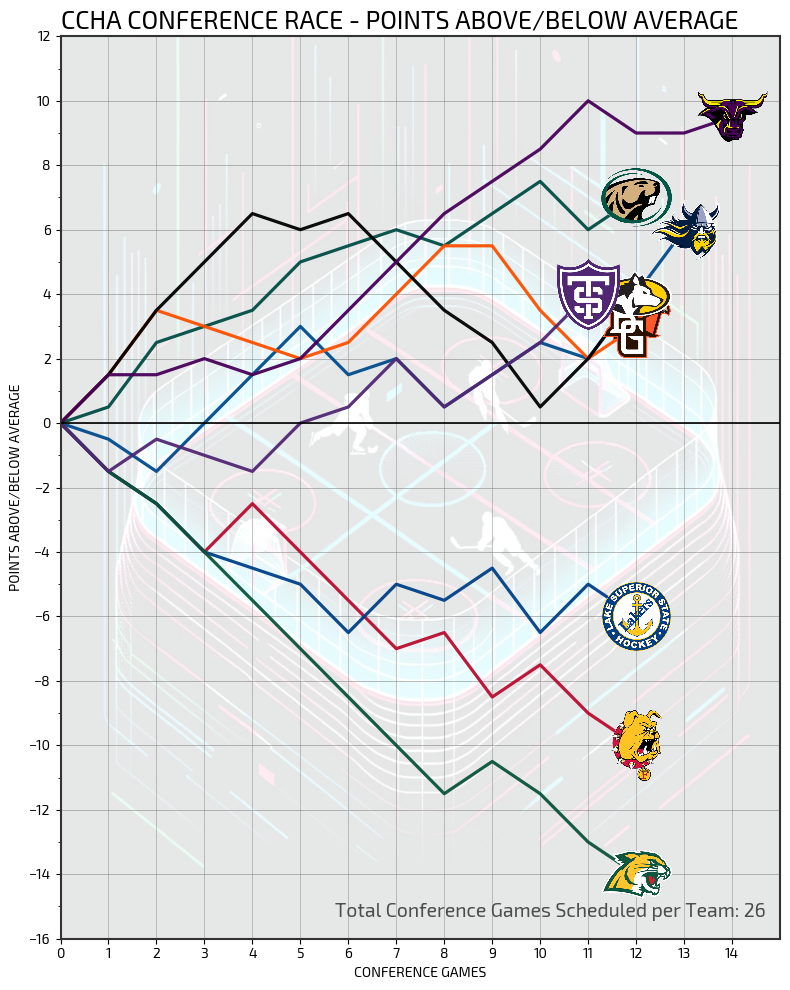

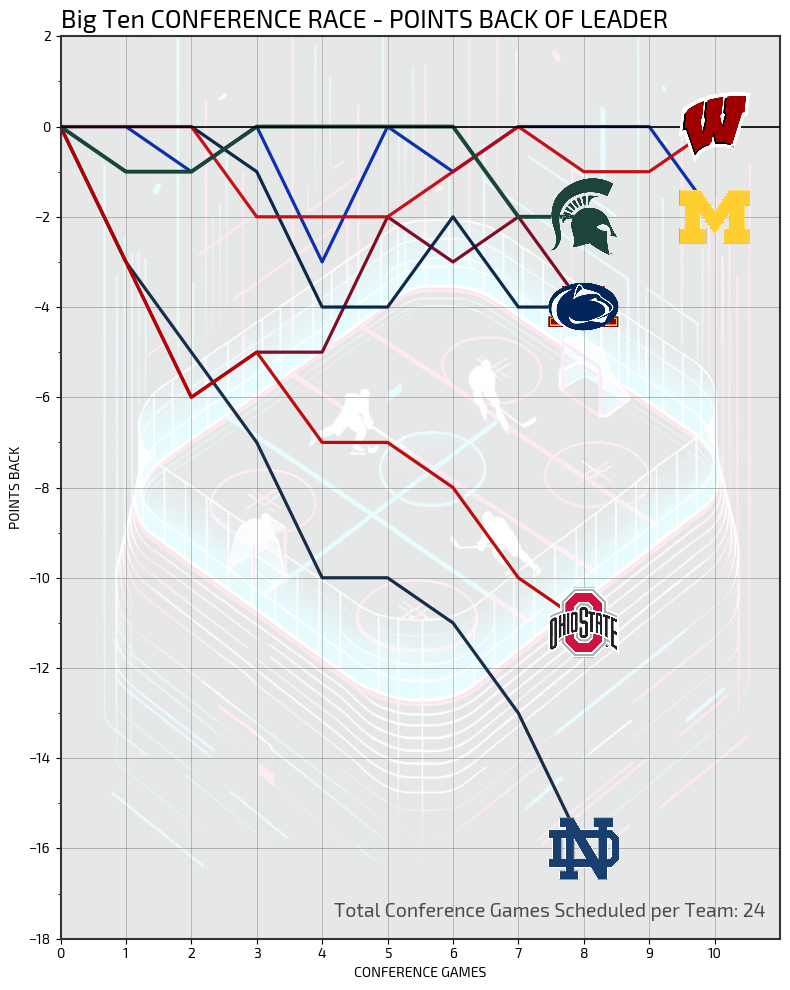

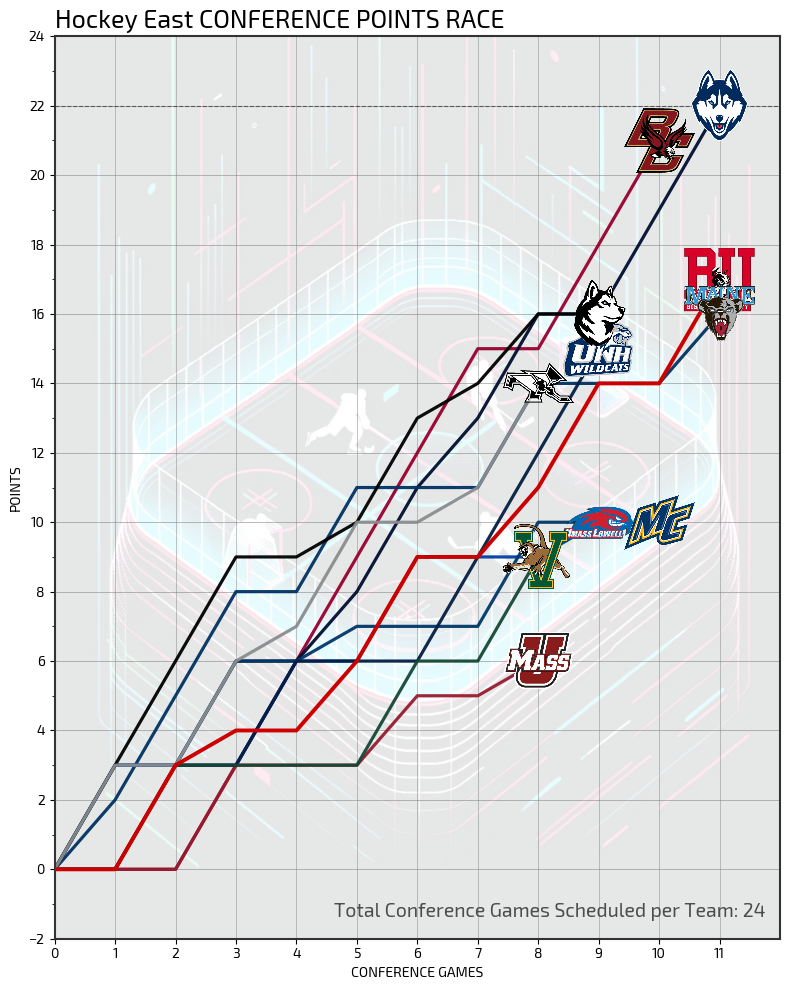

In [30]:
# Build TS (points-based)
ts_df = build_conference_points_time_series(team_games_df)

# Plot cumulative points (simple)
fig, ax = plot_conference_points_race(
    ts_df,
    conf_name="CCHA",
    team_color_mapping=config.team_color_mapping,
    logo_mapping=logo_mapping,
    logo_folder=logo_folder,
    background_img_path=background_img_path2,
    highlight_teams=["Michigan State"],
    logo_zoom=0.17,
    figsize=(8, 10),
    y_mode="points_diff",
)

# Or: points back of leader (keeps the “0-line race” vibe)
fig, ax = plot_conference_points_race(
    ts_df,
    conf_name="Big Ten",
    team_color_mapping=config.team_color_mapping,
    logo_mapping=logo_mapping,
    logo_folder=logo_folder,
    background_img_path=background_img_path2,
    highlight_teams=["Michigan State"],
    logo_zoom=0.17,
    figsize=(8, 10),
    y_mode="points_back",
)

# Or: Total Points
fig, ax = plot_conference_points_race(
    ts_df,
    conf_name="Hockey East",
    team_color_mapping=config.team_color_mapping,
    logo_mapping=logo_mapping,
    logo_folder=logo_folder,
    background_img_path=background_img_path2,
    highlight_teams=["Boston University"],
    logo_zoom=0.17,
    figsize=(8, 10),
    y_mode="points",
)


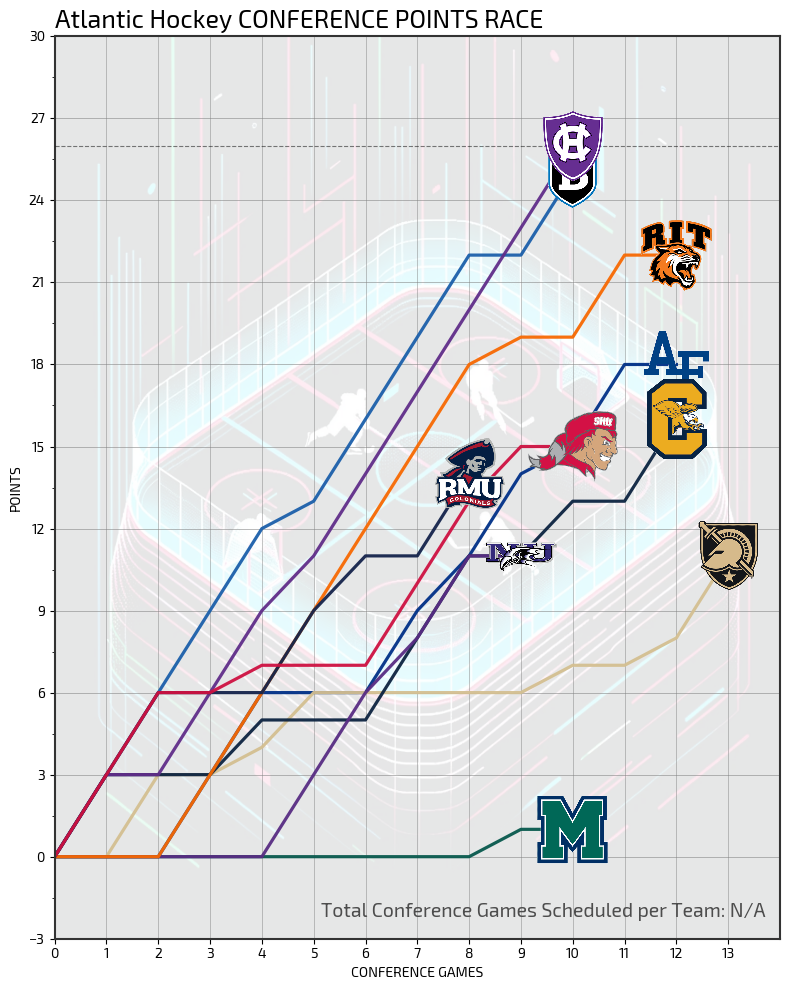

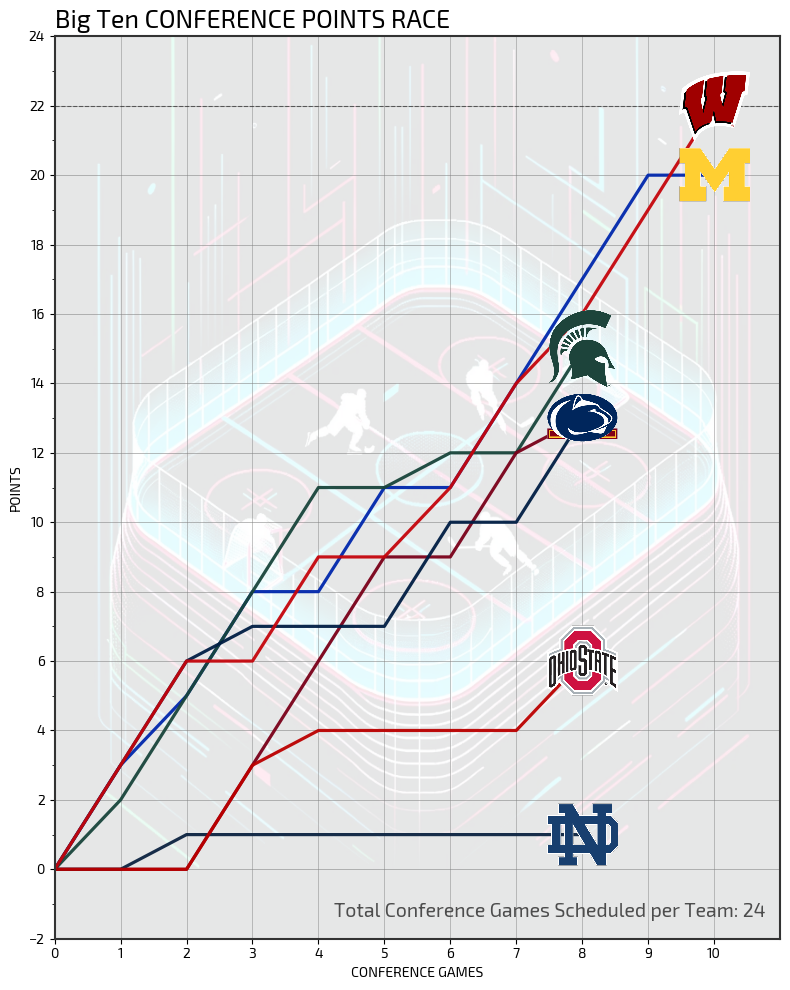

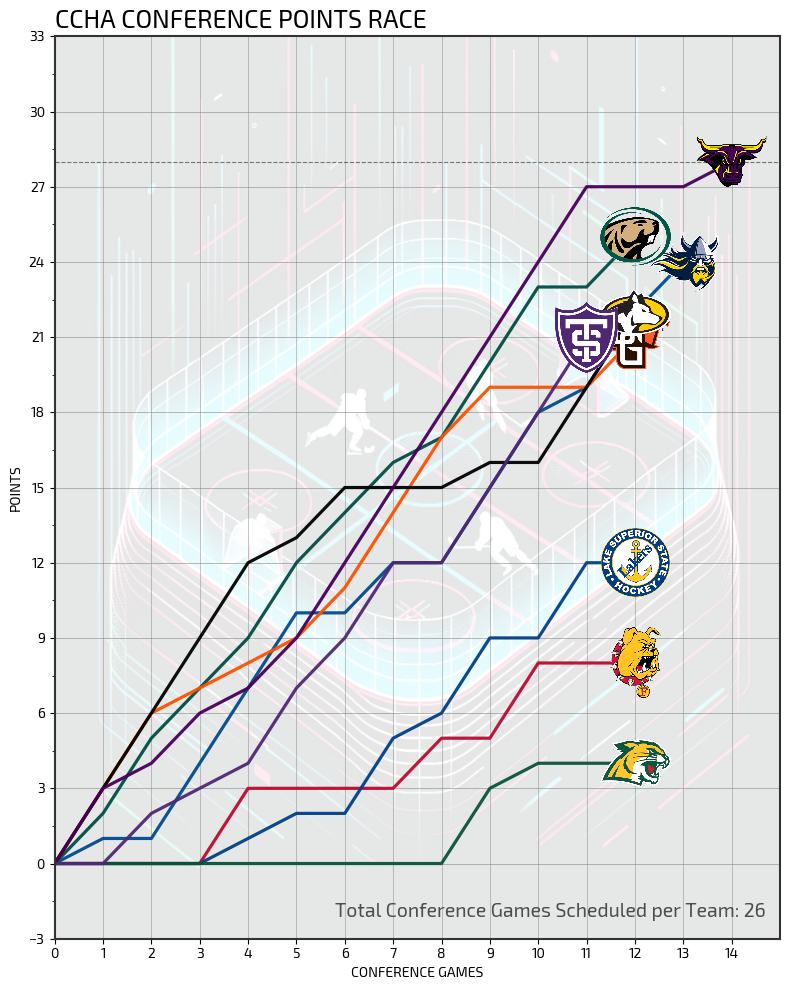

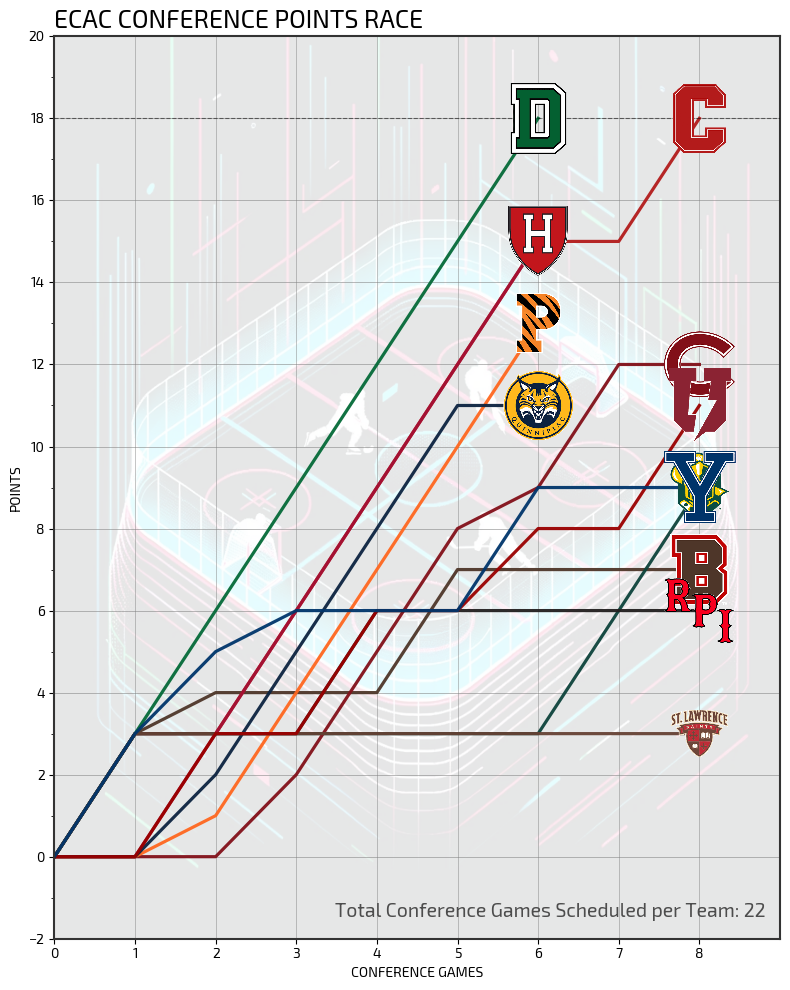

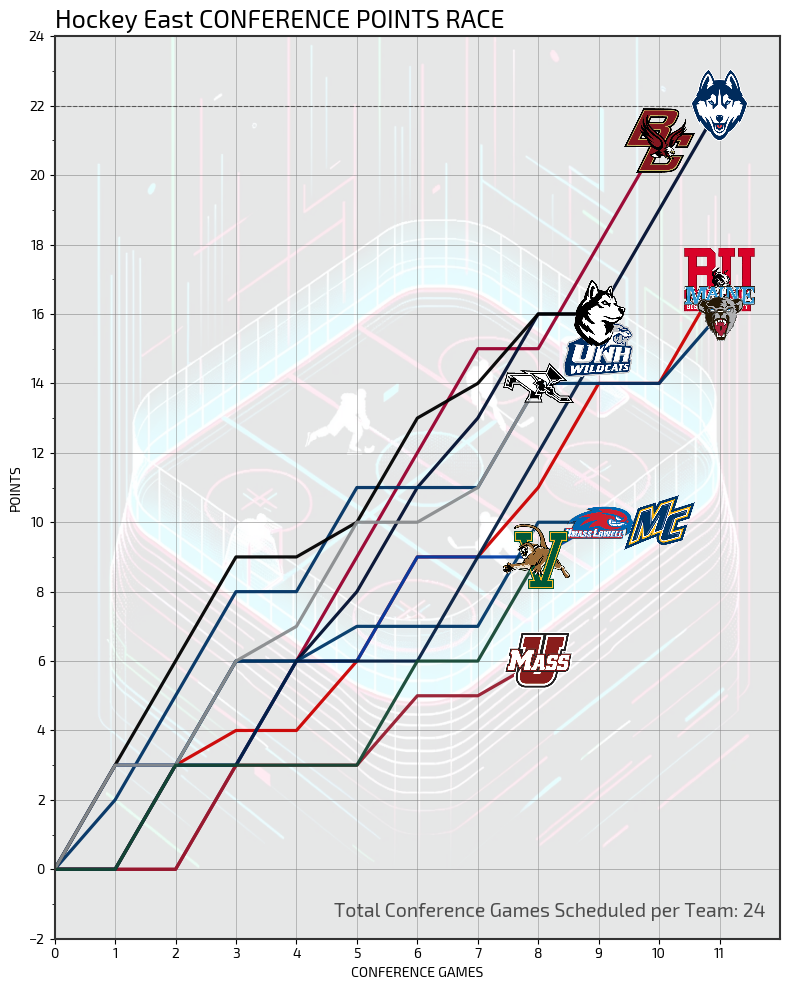

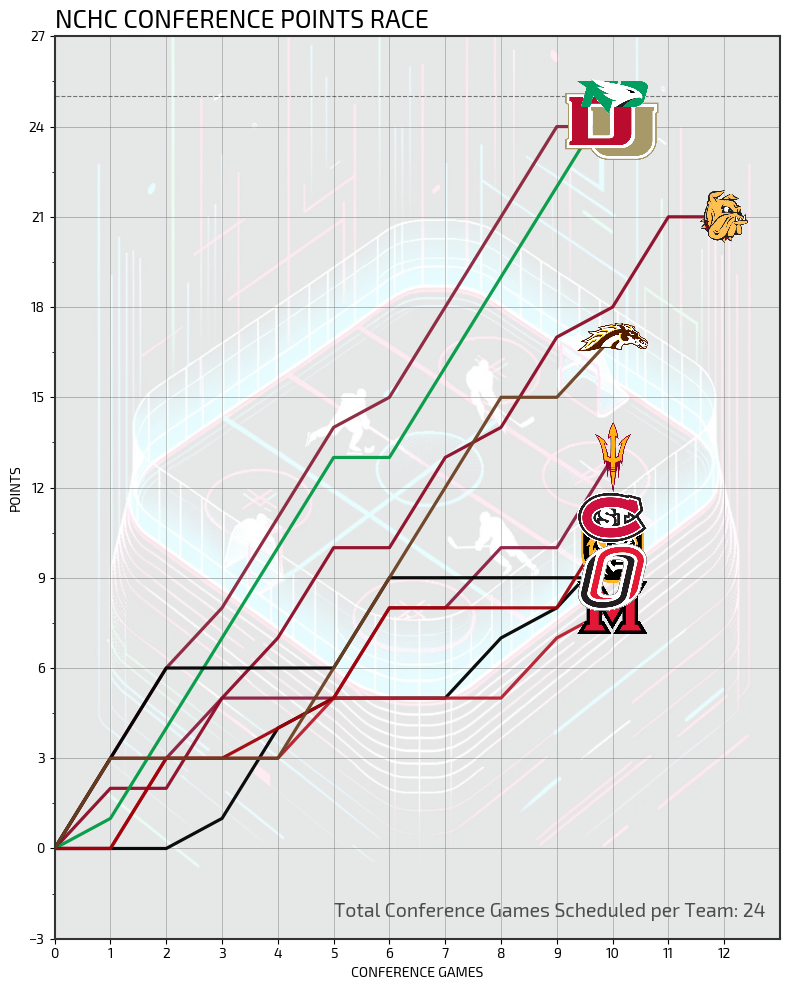

In [31]:
# Create a loop to plot each conference
conf_names = sorted(ts_df["Conference"].unique())

for conf_name in conf_names:
    fig, ax = plot_conference_points_race(
        ts_df,
        conf_name=conf_name,
        team_color_mapping=config.team_color_mapping,
        logo_mapping=logo_mapping,
        logo_folder=logo_folder,
        background_img_path=background_img_path2,
        highlight_teams=None,
        logo_zoom=0.17,
        figsize=(8, 10),
        y_mode="points",
    )

In [32]:
breakpoint

<function breakpoint>

### Original plotting code - Using Points%

In [33]:
# ######### ORIGINAL FUNCTION USING WINS ABOVE AVERAGE POINTS% ##########

# def build_conference_time_series(team_games_df: pd.DataFrame) -> pd.DataFrame:
#     """
#     From team_games_df (one row per *team* per game), build a time series of:
#       - cumulative points
#       - points percentage to date
#       - wins above league-average points%

#     Returns a long dataframe with one row per team per conference game.
#     """

#     # Start from a clean copy
#     df = team_games_df.copy()

#     # Ensure Date is datetime
#     df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

#     # Make sure Team_Points is numeric
#     df["Team_Points"] = pd.to_numeric(df["Team_Points"], errors="coerce")

#     # Drop any rows where we couldn't interpret points
#     df = df.dropna(subset=["Team_Points"]).copy()
#     df["Team_Points"] = df["Team_Points"].astype(int)

#     # Sanity check: we need some conference labels
#     conf_values = sorted(df["Conference"].dropna().unique())
#     print("Conferences in team_games_df:", conf_values)
#     if not conf_values:
#         raise ValueError("No conferences found in team_games_df['Conference'].")

#     all_ts_rows = []

#     # Loop over each conference
#     for conf_name in conf_values:
#         conf_games = df[df["Conference"] == conf_name].copy()
#         if conf_games.empty:
#             continue

#         # --- Final standings to get league-average points% ---
#         final_standings = (
#             conf_games.groupby("Team", as_index=False)
#             .agg(GP=("Game_ID", "count"), Points=("Team_Points", "sum"))
#         )
#         final_standings["Ppct"] = final_standings["Points"] / (3 * final_standings["GP"])

#         league_avg_ppct = final_standings["Ppct"].mean()

#         # --- Per-team, per-game timeline ---
#         conf_games = conf_games.sort_values(["Team", "Date", "Game_ID"])

#         # Game number within conference for each team (x-axis)
#         conf_games["Team_Game_Number"] = conf_games.groupby("Team").cumcount() + 1

#         # Cumulative points for each team
#         conf_games["Cum_Points"] = conf_games.groupby("Team")["Team_Points"].cumsum()

#         # Points% to date
#         conf_games["Ppct_to_date"] = (
#             conf_games["Cum_Points"] / (3 * conf_games["Team_Game_Number"])
#         )

#         # Wins above league-average points% to date
#         # (Cum_Points / 3) - GP * league_avg_ppct
#         conf_games["Wins_Above_Avg"] = (
#             conf_games["Cum_Points"] / 3.0
#             - conf_games["Team_Game_Number"] * league_avg_ppct
#         )

#         conf_games["League_Avg_Ppct"] = league_avg_ppct

#         all_ts_rows.append(conf_games)

#         print(f"{conf_name}: league avg P% = {league_avg_ppct:.3f}")

#     if not all_ts_rows:
#         raise ValueError("No conference games available to build time series.")

#     ts_df = pd.concat(all_ts_rows, ignore_index=True)
#     return ts_df


In [34]:
ts_df = build_conference_time_series(team_games_df)
ts_df.head()



NameError: name 'build_conference_time_series' is not defined

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd
# from matplotlib.ticker import MultipleLocator
# from pathlib import Path

# def plot_conference_wins_above_avg(
#     ts_df: pd.DataFrame,
#     conf_name: str,
#     team_color_mapping: dict | None = None,
#     logo_mapping: dict | None = None,
#     logo_folder: str | None = None,
#     highlight_teams: list[str] | None = None,
#     background_img_path: str | None = None,
#     logo_zoom: float = 0.17,
#     figsize=(10, 6),
# ):
#     """
#     Plot 'wins above league-average points%' over conference games for one conference,
#     with team logos at the terminal end of each line and optional background image.
#     """
#     conf_ts = ts_df[ts_df["Conference"] == conf_name].copy()
#     if conf_ts.empty:
#         print(f"No data for conference {conf_name}")
#         return None, None

#     league_avg_ppct = conf_ts["League_Avg_Ppct"].iloc[0]

#     # --------- RANGES / MARGINS ---------
#     max_gp = int(conf_ts["Team_Game_Number"].max())

#     # Symmetric y-range around 0 so it feels like the NHL chart
#     ymin = conf_ts["Wins_Above_Avg"].min()
#     ymax = conf_ts["Wins_Above_Avg"].max()
#     y_lim = max(abs(ymin), abs(ymax))
#     y_lim = np.ceil(y_lim)  # whole wins
#     y_margin = 0.5          # small breathing room
#     y_min = -y_lim - y_margin
#     y_max = y_lim + y_margin

#     fig, ax = plt.subplots(figsize=figsize)

#     # --------- BACKGROUND IMAGE (optional) ---------
#     if background_img_path is not None:
#         bg_path = Path(background_img_path)
#         if bg_path.exists():
#             try:
#                 bg_img = plt.imread(str(bg_path))
#                 ax.imshow(
#                     bg_img,
#                     extent=(0, max_gp + 1, y_min, y_max),
#                     aspect="auto",
#                     zorder=0,
#                     alpha=0.1,
#                 )
#                 ax.set_facecolor("none")
#             except Exception as e:
#                 print(f"Error loading background image: {e}")
#         else:
#             print(f"Background image not found at: {bg_path}")
#     else:
#         # Plain white background like the reference
#         ax.set_facecolor("white")

#     terminal_points = []

#     # --------- LINES ---------
#     for team, g in conf_ts.groupby("Team"):
#         g = g.sort_values("Team_Game_Number")

#         # Color handling (tuple/list/dict/string)
#         color = None
#         if team_color_mapping is not None:
#             raw = team_color_mapping.get(team)
#             if isinstance(raw, (list, tuple)) and len(raw) > 0:
#                 color = raw[0]
#             elif isinstance(raw, dict) and raw:
#                 color = raw.get("primary") or next(iter(raw.values()))
#             else:
#                 color = raw

#         is_highlight = highlight_teams is not None and team in highlight_teams
#         lw = 2.5 if is_highlight else 2.5
#         alpha = 1.0 if is_highlight else 1.0
#         zorder = 3 if is_highlight else 2

#         plot_kwargs = dict(
#             linewidth=lw,
#             alpha=alpha,
#             zorder=zorder,
#             label=team,
#         )
#         if color is not None:
#             plot_kwargs["color"] = color

#         ax.plot(
#             g["Team_Game_Number"],
#             g["Wins_Above_Avg"],
#             **plot_kwargs,
#         )

#         last_row = g.iloc[-1]
#         terminal_points.append(
#             {
#                 "Team": team,
#                 "x": last_row["Team_Game_Number"],
#                 "y": last_row["Wins_Above_Avg"],
#             }
#         )

#     # --------- AXIS LIMITS ---------
#     # x from 0 like the NHL plot, even though data starts at 1
#     ax.set_xlim(-0.35, max_gp + 1)
#     ax.set_xticks(range(0, max_gp + 1))

#     ax.set_ylim(y_min, y_max)

#     # --------- TICKS & GRID (NHL-style) ---------
#     # x: tick at every game
#     ax.set_xticks(range(0, max_gp + 1))

#     # y: integer wins
#     ax.yaxis.set_major_locator(MultipleLocator(1.0))

#     # vertical grid (game ticks)
#     ax.grid(
#         which="major",
#         axis="x",
#         linestyle="-",
#         linewidth=0.5,
#         color="grey",
#         alpha=0.65,
#         zorder=1,
#     )

#     # horizontal grid (wins)
#     ax.grid(
#         which="major",
#         axis="y",
#         linestyle="-",
#         linewidth=0.7,
#         color="grey",
#         alpha=0.55,
#         zorder=1,
#     )

#     # # Light grid both directions – similar to the example
#     # ax.grid(
#     #     which="major",
#     #     axis="both",
#     #     linestyle="-",
#     #     linewidth=0.6,
#     #     color="white",
#     #     alpha=0.7,
#     # )

#     # Bold 0-line (league-average) like the reference
#     ax.axhline(0, color="black", linewidth=1.2, linestyle="-", zorder=4)

#     # --------- SPINES / FRAME (dark border) ---------
#     for spine in ax.spines.values():
#         spine.set_linewidth(1.5)
#         spine.set_color("0.2")

#     # --------- LABELS / TITLE ---------
#     ax.set_xlabel("CONFERENCE GAMES")
#     ax.set_ylabel("WINS")
#     ax.set_title(f"{conf_name} – WINS ABOVE LEAGUE AVG P%", loc="left", fontsize=14, weight="bold")

#     # Optional: right-side text for league avg, like the .572 in the NHL chart
#     ax.text(
#         max_gp + 0.9,
#         0,
#         f"{league_avg_ppct:.3f}",
#         va="center",
#         ha="left",
#         fontsize=9,
#     )

#     # --------- LOGOS AT TERMINAL POINTS ---------
#     if logo_mapping is not None and logo_folder is not None and len(terminal_points) > 0:
#         logo_df = pd.DataFrame(terminal_points)
#         add_logos_to_plot(
#             data_df=logo_df,
#             x_col="x",
#             y_col="y",
#             logo_mapping=logo_mapping,
#             logo_folder=logo_folder,
#             ax=ax,
#             teams_in_region=logo_df["Team"].tolist(),
#             zoom=logo_zoom,
#         )

#     # No legend; logos carry identity
#     # ax.legend(loc="best", fontsize=8)

#     plt.tight_layout()
#     return fig, ax


In [ ]:
# fig, ax = plot_conference_wins_above_avg(
#     ts_df,
#     conf_name="ECAC",
#     team_color_mapping=config.team_color_mapping,
#     logo_mapping=logo_mapping,
#     logo_folder=logo_folder,
#     background_img_path=background_img_path2,  # or your custom bg path
#     highlight_teams=["Michigan State"],
#     logo_zoom=0.17,
#     figsize=(8, 10),
# )
